# Conjunto nacional de información edafológica. Escala 1:250 000 Serie III.  

Tema:	Edafología  
Colección:	Cartas Edafológicas  
Entidad federativa:	Estados Unidos Mexicanos  
Edición:	2024  
Cobertura temporal:	10/03/2021  
Formato:	Electrónico  
Escala:	1:250 000  
Proyección:	Cónica Conforme de Lambert  
Coordenadas:	O 86° 00' 00" - O 120° 00' 00" / N 14° 00' 00" - N 33° 00' 00"  
Datum:	ITRF92 época 1988.0  
Contiene información actualizada de los diferentes grupos de suelos que existen en el territorio mexicano obtenida durante el período 2013-2020, utilizando para la clasificación de los suelos el Sistema de la Base Referencial Mundial del Recurso Suelo de la WRB 2014 (por sus siglas en inglés). El producto muestra la distribución espacial de los suelos presentes en México.  

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd

from proyecto_agronomia.config import (
    EDAFOLOGIA_RAW_DIR,
)

from proyecto_agronomia.dataset import (
    descargar_edafologia_inegi,
)

2026-10-03 17:15:48.589 | INFO     | proyecto_agronomia.config:<module>:14 - PROJ_ROOT path is: B:\MCD2\JW\agro\proyecto_agronomia


## 1. Adquisición de los datos edafológicos

La información se descarga programáticamente desde INEGI.

El archivo original corresponde a un conjunto vectorial nacional en
formato Shapefile distribuido dentro de un archivo ZIP.

Siguiendo la estructura de Cookiecutter Data Science, los archivos
originales se conservan sin modificaciones dentro de:

`data/raw/edafologia/`

La función de adquisición verifica si el archivo ya existe localmente
antes de realizar una nueva descarga.

In [2]:
ruta_edafologia = descargar_edafologia_inegi()

print(
    f"Directorio de datos edafológicos: "
    f"{ruta_edafologia}"
)

2026-10-03 17:15:48.991 | INFO     | proyecto_agronomia.datasets.edafologia:descargar_edafologia_inegi:90 - El archivo edafológico ya existe.
2026-10-03 17:15:49.001 | INFO     | proyecto_agronomia.datasets.edafologia:descargar_edafologia_inegi:95 - Los datos edafológicos ya fueron extraídos.
Directorio de datos edafológicos: B:\MCD2\JW\agro\proyecto_agronomia\data\raw\edafologia\serie_iii


In [3]:
archivos_shp = list(
    ruta_edafologia.rglob("*.shp")
)

print(
    f"Archivos SHP encontrados: "
    f"{len(archivos_shp)}"
)

for archivo in archivos_shp:
    print(archivo.relative_to(ruta_edafologia))

Archivos SHP encontrados: 2
conjunto_de_datos\conj_nac_inf_edaf_esc_250k_ser_III_area.shp
conjunto_de_datos\conj_nac_inf_edaf_esc_250k_ser_III_pto.shp


In [4]:
ruta_area = next(
    ruta_edafologia.rglob(
        "*_area.shp"
    )
)

ruta_punto = next(
    ruta_edafologia.rglob(
        "*_pto.shp"
    )
)

edafologia_area = gpd.read_file(
    ruta_area
)

edafologia_punto = gpd.read_file(
    ruta_punto
)

print("CAPA DE ÁREAS")
print("----------------")
print(f"Registros: {len(edafologia_area):,}")
print(f"Columnas: {len(edafologia_area.columns)}")
print(f"CRS: {edafologia_area.crs}")
print(
    "Geometrías:",
    edafologia_area.geometry.geom_type.value_counts().to_dict(),
)

print()

print("CAPA DE PUNTOS")
print("----------------")
print(f"Registros: {len(edafologia_punto):,}")
print(f"Columnas: {len(edafologia_punto.columns)}")
print(f"CRS: {edafologia_punto.crs}")
print(
    "Geometrías:",
    edafologia_punto.geometry.geom_type.value_counts().to_dict(),
)

CAPA DE ÁREAS
----------------
Registros: 73,356
Columnas: 17
CRS: PROJCS["ITRF_1992_Lambert_Conformal_Conic",GEOGCS["ITRF92",DATUM["International_Terrestrial_Reference_Frame_1992",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6651"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",12],PARAMETER["central_meridian",-102],PARAMETER["standard_parallel_1",17.5],PARAMETER["standard_parallel_2",29.5],PARAMETER["false_easting",2500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Geometrías: {'Polygon': 73356}

CAPA DE PUNTOS
----------------
Registros: 20,714
Columnas: 115
CRS: PROJCS["ITRF_1992_Lambert_Conformal_Conic",GEOGCS["ITRF92",DATUM["International_Terrestrial_Reference_Frame_1992",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6651"]],PRIMEM["Greenwich",0

## 2. Inspección de las capas vectoriales

El conjunto nacional contiene dos capas principales en formato
Shapefile:

- una capa identificada como `area`;
- una capa identificada como `pto`.

Antes de realizar transformaciones o seleccionar variables, se cargan
ambas capas para identificar su geometría, sistema de referencia,
dimensiones y atributos.

Esta exploración permitirá determinar la función de cada capa dentro
del conjunto edafológico y seleccionar posteriormente la información
relevante para el análisis municipal.

In [5]:
print("COLUMNAS — ÁREAS")
for columna in edafologia_area.columns:
    print(f"- {columna}")

print()

print("COLUMNAS — PUNTOS")
for columna in edafologia_punto.columns:
    print(f"- {columna}")

COLUMNAS — ÁREAS
- OBJECTID
- Clave_wrb
- Grupo1
- Califp_g1
- Califs_g1
- Grupo2
- Califp_g2
- Califs_g2
- Grupo3
- Califp_g3
- Clase_tex
- Lmte_sup
- Fase_fis_u
- Fase_qui_u
- Shape_Leng
- Shape_Area
- geometry

COLUMNAS — PUNTOS
- OBJECTID
- Id_Sitio
- Id_Hte
- Numero_Hte
- Limite_sup
- Limite_inf
- Contra_hte
- Forma_hor
- HCl
- H2O2
- Humed_apar
- Forma_estr
- Tam_gr_la
- Tam_pr_co
- Tam_bl_mi
- Desar_estr
- Peliculas
- Pel_natur
- Facetas
- Grietas
- Col_hum_c
- Col_seco_c
- Cons_seco
- Cons_hum
- Adhesivid
- Plasticid
- Text_campo
- Gravas
- Piedras
- Concrecion
- Conc_color
- Nodulos
- Nodu_color
- Manchas
- Manch_colo
- Raices
- Cementac
- Nomen_hte
- Horiz_diag
- Prop_diag1
- Mater_diag
- Horiz_di_1
- Prop_diag2
- Mater_di_1
- Horiz_di_2
- Prop_diag3
- Mater_di_2
- R
- L
- A
- Desc_r_l_a
- Clase_text
- Esq_grava
- Esq_piedra
- Col_seco_l
- Col_hum_l
- CE
- pH
- CO
- CIC
- SB
- SNa
- K
- Ca
- Na
- Mg
- P2O5
- CaCO3
- CaSO4
- DA
- Na_Mg
- Id_foto
- Cal_pos
- FID_
- OBJECTID_1
-

In [6]:
display(
    edafologia_area
    .drop(columns="geometry")
    .head()
)

display(
    edafologia_punto
    .drop(columns="geometry")
    .head()
)

,OBJECTID,Clave_wrb,Grupo1,Califp_g1,Califs_g1,Grupo2,Califp_g2,Califs_g2,Grupo3,Califp_g3,Clase_tex,Lmte_sup,Fase_fis_u,Fase_qui_u,Shape_Leng,Shape_Area
0,51100,TCek-ub,TC,ek,ub,N,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,4869.986820,1.279462e+06
1,51101,TCek-ub,TC,ek,ub,N,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,13456.884838,4.277815e+06
2,51102,TCek-ub,TC,ek,ub,N,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,7494.539810,2.320522e+06
3,51103,TCek-ub,TC,ek,ub,N,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,4987.291306,1.022117e+06
4,51104,TCek-ub,TC,ek,ub,N,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,17304.215845,6.533944e+06


,OBJECTID,Id_Sitio,Id_Hte,Numero_Hte,Limite_sup,Limite_inf,Contra_hte,Forma_hor,HCl,H2O2,...,Pedreg_sup,Afloramien,Escurr_sup,Infiltra,Superf_sue,Tipo_eros,Forma_eros,Grado_eros,Influe_hum,Fact_nociv
0,462,F1202-306,F1202-306-1,1,0,45,Abrupto,Plana,Muy débil,No disponible,...,Ninguno,Ninguno,Medio,Drenado,Ninguno,Hídrica,Laminar,Leve,Escasa,Otro
1,463,F1206-301,F1206-301-1,1,0,30,Abrupto,Irregular,Muy débil,No disponible,...,Ninguno,Ninguno,Medio,Drenado,Ninguno,Hídrica,Laminar,Moderado,Moderada,Sobrepastoreo
2,464,F1203-310,F1203-310-1,1,0,14,Abrupto,Irregular,Muy débil,No disponible,...,Ninguno,Ninguno,Medio,Drenado,Otros,Hídrica,Laminar,Moderado,Moderada,Ninguno
3,465,F1203-309,F1203-309-1,1,0,10,Abrupto,Plana,Muy débil,No disponible,...,Ninguno,Ninguno,Medio,Drenado,Otros,Hídrica,Laminar,Leve,Escasa,Ninguno
4,466,F1203-307,F1203-307-1,1,0,24,Abrupto,Plana,Muy débil,No disponible,...,Ninguno,Ninguno,Medio,Drenado,Otros,Hídrica,Laminar,Leve,Escasa,Ninguno


In [7]:
def resumir_columnas(gdf):
    resumen = []

    for columna in gdf.columns:
        if columna == "geometry":
            continue

        resumen.append({
            "columna": columna,
            "tipo": str(gdf[columna].dtype),
            "valores_unicos": gdf[columna].nunique(
                dropna=True
            ),
            "nulos": gdf[columna].isna().sum(),
        })

    return pd.DataFrame(resumen)


resumen_area = resumir_columnas(
    edafologia_area
)

resumen_punto = resumir_columnas(
    edafologia_punto
)

display(resumen_area)
display(resumen_punto)

,columna,tipo,valores_unicos,nulos
0,OBJECTID,int64,73356,0
1,Clave_wrb,str,26507,0
2,Grupo1,str,29,0
3,Califp_g1,str,132,0
4,Califs_g1,str,153,0
5,Grupo2,str,29,0
6,Califp_g2,str,137,0
7,Califs_g2,str,124,0
8,Grupo3,str,29,0
9,Califp_g3,str,102,0


,columna,tipo,valores_unicos,nulos
0,OBJECTID,int64,20714,0
1,Id_Sitio,str,5318,0
2,Id_Hte,str,20714,0
3,Numero_Hte,int64,12,0
4,Limite_sup,int64,145,0
...,...,...,...,...
109,Tipo_eros,str,5,0
110,Forma_eros,str,8,0
111,Grado_eros,str,6,0
112,Influe_hum,str,6,0


## 3. Exploración de las unidades edafológicas

La capa de áreas contiene 73,356 polígonos que representan unidades
edafológicas distribuidas en el territorio nacional.

Cada unidad contiene información sobre los grupos de suelo presentes,
sus calificadores y algunas características generales de la unidad,
como clase textural y fases físicas o químicas.

Esta capa será utilizada como fuente principal para caracterizar
edafológicamente los municipios.

La capa puntual contiene información considerablemente más detallada
sobre sitios y horizontes de suelo. Se conservará como parte de los
datos originales, pero no será incorporada inicialmente al conjunto
analítico municipal.

In [8]:
columnas_interes = [
    "Grupo1",
    "Grupo2",
    "Grupo3",
    "Clase_tex",
    "Lmte_sup",
    "Fase_fis_u",
    "Fase_qui_u",
]

for columna in columnas_interes:
    print(f"\n{'=' * 60}")
    print(f"{columna}")
    print("=" * 60)

    print(
        edafologia_area[columna]
        .value_counts(dropna=False)
        .to_string()
    )


Grupo1
Grupo1
LP    15211
RG    10590
PH     8856
CL     7883
VR     4749
LV     4392
CM     3705
SA     3579
TC     2878
SC     1626
FL     1566
GL     1480
KS     1357
AN      934
AR      738
CH      734
GY      511
UM      504
AC      372
AL      371
DU      327
SN      264
LX      232
PL      200
ST      148
NT       98
PT       23
HS       20
AT        8

Grupo2
Grupo2
N      25782
RG      9351
LP      8921
PH      5912
CM      4163
N/A     3579
LV      3345
VR      3001
CL      2954
FL      1071
GL       704
AR       690
SC       685
KS       685
AN       450
CH       349
UM       331
SN       211
GY       197
PL       187
AC       183
DU       178
AL       155
LX       146
ST        56
PT        27
NT        22
HS        16
TC         5

Grupo3
Grupo3
N      35322
N/A    29364
LP      2100
RG      1631
CM      1155
PH      1131
LV       614
VR       574
CL       346
FL       321
AR       153
GL        94
AN        79
SC        77
PL        65
KS        63
UM        57
CH       

In [9]:
grupos_suelo = sorted(
    edafologia_area["Grupo1"]
    .dropna()
    .unique()
)

print(
    f"Grupos principales encontrados: "
    f"{len(grupos_suelo)}"
)

for grupo in grupos_suelo:
    print(grupo)

Grupos principales encontrados: 29
AC
AL
AN
AR
AT
CH
CL
CM
DU
FL
GL
GY
HS
KS
LP
LV
LX
NT
PH
PL
PT
RG
SA
SC
SN
ST
TC
UM
VR


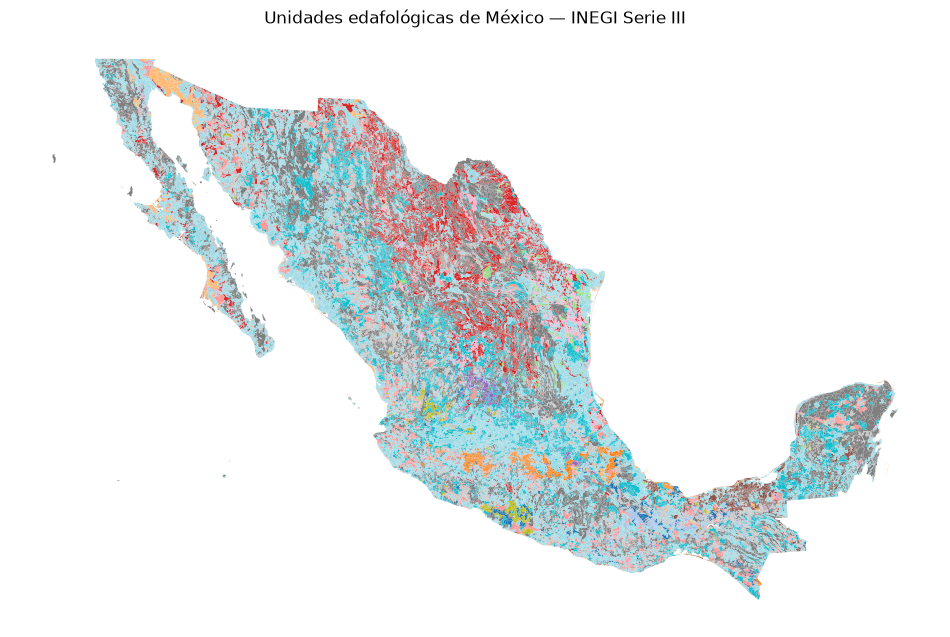

In [10]:
ax = edafologia_area.plot(
    column="Grupo1",
    figsize=(12, 10),
    legend=False,
)

ax.set_title(
    "Unidades edafológicas de México — INEGI Serie III"
)

ax.set_axis_off()

In [11]:
from proyecto_agronomia.dataset import (
    descargar_diccionario_edafologia,
    descargar_edafologia_inegi,
)

In [12]:
ruta_diccionario = descargar_diccionario_edafologia()

print(
    f"Diccionario edafológico: "
    f"{ruta_diccionario}"
)

2026-10-03 17:17:12.448 | INFO     | proyecto_agronomia.datasets.edafologia:descargar_diccionario_edafologia:150 - El diccionario edafológico ya existe.
Diccionario edafológico: B:\MCD2\JW\agro\proyecto_agronomia\references\edafologia\diccionario_datos_edafologicos_250k_v4.pdf


## 4. Interpretación de los atributos edafológicos

El conjunto vectorial utiliza códigos y categorías definidos por INEGI
en el **Diccionario de Datos Edafológicos, escala 1:250 000,
versión 4**.

La capa de áreas contiene información sobre el suelo dominante,
secundario y terciario de cada unidad edafológica, además de
características como clase textural, limitantes superficiales y fases
físicas o químicas.

Antes de construir variables municipales se inspeccionan los dominios
de estos atributos para determinar cuáles son relevantes para el
análisis agrícola.

In [13]:
columnas_interes = [
    "Grupo1",
    "Grupo2",
    "Grupo3",
    "Clase_tex",
    "Lmte_sup",
    "Fase_fis_u",
    "Fase_qui_u",
]

for columna in columnas_interes:
    valores = sorted(
        edafologia_area[columna]
        .astype(str)
        .unique()
    )

    print(
        f"{columna} "
        f"({len(valores)} valores)"
    )

    print(valores)
    print()

Grupo1 (29 valores)
['AC', 'AL', 'AN', 'AR', 'AT', 'CH', 'CL', 'CM', 'DU', 'FL', 'GL', 'GY', 'HS', 'KS', 'LP', 'LV', 'LX', 'NT', 'PH', 'PL', 'PT', 'RG', 'SA', 'SC', 'SN', 'ST', 'TC', 'UM', 'VR']

Grupo2 (29 valores)
['AC', 'AL', 'AN', 'AR', 'CH', 'CL', 'CM', 'DU', 'FL', 'GL', 'GY', 'HS', 'KS', 'LP', 'LV', 'LX', 'N', 'N/A', 'NT', 'PH', 'PL', 'PT', 'RG', 'SC', 'SN', 'ST', 'TC', 'UM', 'VR']

Grupo3 (29 valores)
['AC', 'AL', 'AN', 'AR', 'CH', 'CL', 'CM', 'DU', 'FL', 'GL', 'GY', 'HS', 'KS', 'LP', 'LV', 'LX', 'N', 'N/A', 'NT', 'PH', 'PL', 'PT', 'RG', 'SC', 'SN', 'ST', 'TC', 'UM', 'VR']

Clase_tex (4 valores)
['1', '2', '3', 'N/A']

Lmte_sup (5 valores)
['G', 'N', 'N/A', 'P', 'p']

Fase_fis_u (11 valores)
['N', 'N/A', 'len', 'lep', 'li', 'pcn', 'pcp', 'pdn', 'pdp', 'pgn', 'pgp']

Fase_qui_u (7 valores)
['N', 'N/A', 'jz', 'qs', 'qz', 'so', 'sz']



### Dominios de los atributos

La exploración muestra que los principales atributos edafológicos se
encuentran codificados.

Se identificaron:

- 29 valores para el grupo de suelo dominante (`Grupo1`);
- 29 valores para los grupos secundario y terciario;
- 4 valores para clase textural;
- 5 valores para limitante superficial;
- 11 valores para fase física;
- 7 valores para fase química.

Estos códigos no serán interpretados directamente ni sustituidos por
descripciones construidas por el proyecto.

Su significado se obtendrá del Diccionario de Datos Edafológicos
oficial de INEGI, conservado en `references/edafologia/`.